In [1]:
import os
import cv2
import yaml
import random
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
from tqdm import tqdm

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammadharisabid/fabricdefectntu")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/muhammadharisabid/fabricdefectntu


In [4]:
yaml_path = "/kaggle/input/datasets/muhammadharisabid/fabricdefectntu/data.yaml"

with open(yaml_path, "r") as file:
    data = yaml.safe_load(file)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 7, 'names': ['baekra', 'color issues', 'contamination', 'cut', 'gray stitch', 'selvet', 'stain'], 'roboflow': {'workspace': 'seecs-z4uae', 'project': 'fabricdd', 'version': 2, 'license': 'Private', 'url': 'https://app.roboflow.com/seecs-z4uae/fabricdd/2'}}


In [5]:
class_names = data["names"]

num_classes = data["nc"]

print("="*50)

print("Number of Classes :", num_classes)

print("="*50)

for idx, cls in enumerate(class_names):
    print(f"{idx} --> {cls}")

Number of Classes : 7
0 --> baekra
1 --> color issues
2 --> contamination
3 --> cut
4 --> gray stitch
5 --> selvet
6 --> stain


In [6]:
# ============================================
# Dataset Folders
# ============================================

train_images = Path("/kaggle/input/datasets/muhammadharisabid/fabricdefectntu/train/images")
train_labels = Path("/kaggle/input/datasets/muhammadharisabid/fabricdefectntu/train/labels")

valid_images = Path("/kaggle/input/datasets/muhammadharisabid/fabricdefectntu/valid/images")
valid_labels = Path("/kaggle/input/datasets/muhammadharisabid/fabricdefectntu/valid/labels")

test_images = Path("/kaggle/input/datasets/muhammadharisabid/fabricdefectntu/test/images")
test_labels = Path("/kaggle/input/datasets/muhammadharisabid/fabricdefectntu/test/images")

In [7]:
train_count = len(list(train_images.glob("*")))

valid_count = len(list(valid_images.glob("*")))

test_count = len(list(test_images.glob("*")))

print("="*50)

print("Training Images :", train_count)

print("Validation Images :", valid_count)

print("Testing Images :", test_count)

print("="*50)

Training Images : 1950
Validation Images : 562
Testing Images : 280


In [8]:
train_count_labels = len(list(train_labels.glob("*.txt")))
valid_count_labels = len(list(valid_labels.glob("*.txt")))
test_count_labels = len(list(test_labels.glob("*.txt")))

print("="*50)
print("Training Labels :", train_count_labels)

print("Validation Labels :", valid_count_labels)

print("Testing Labels :", test_count_labels)

print("="*50)

Training Labels : 1950
Validation Labels : 562
Testing Labels : 0


In [9]:
missing_labels = []

for image_path in train_images.glob("*"):

    label_path = train_labels / f"{image_path.stem}.txt"

    if not label_path.exists():

        missing_labels.append(image_path.name)

print("Missing Labels :", len(missing_labels))

Missing Labels : 0


In [11]:
class_counter = Counter()

for label_file in tqdm(train_labels.glob("*.txt")):

    with open(label_file, "r") as f:
        lines = f.readlines()

    for line in lines:

        cls = int(float(line.split()[0]))

        class_counter[class_names[cls]] += 1

for cls, count in class_counter.items():
    print(f"{cls:<20}: {count}")

1950it [00:05, 373.42it/s]

baekra              : 245
stain               : 963
gray stitch         : 333
selvet              : 421
cut                 : 346
color issues        : 232
contamination       : 169


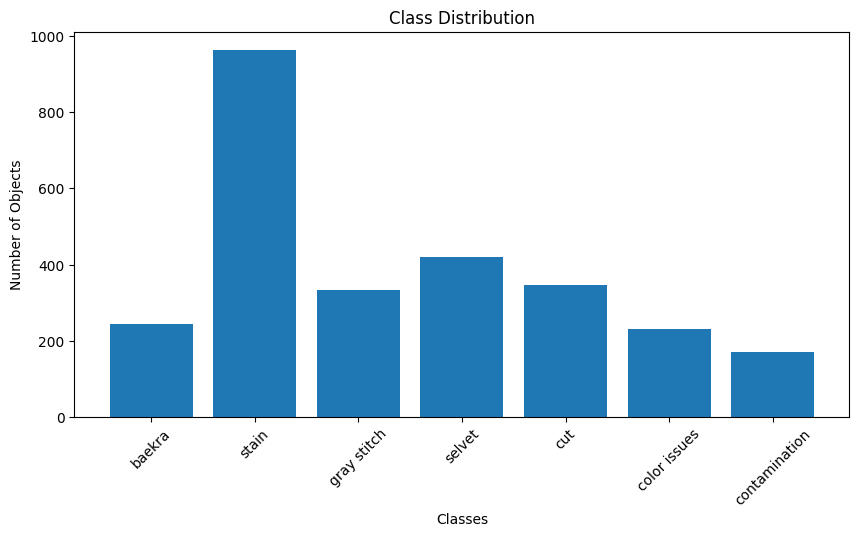

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_counter.keys(),
    class_counter.values()
)

plt.xticks(rotation=45)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Objects")

plt.show()

In [13]:
corrupted = []

for image_path in tqdm(train_images.glob("*")):

    image = cv2.imread(str(image_path))

    if image is None:
        corrupted.append(image_path.name)

print("Corrupted Images:", len(corrupted))

1950it [00:34, 57.15it/s]

Corrupted Images: 0


In [15]:
# ============================================
# Dataset Summary
# ============================================

print("\n")

print("="*60)

print("TEXTILE FABRIC DEFECT DATASET SUMMARY")

print("="*60)

print(f"Training Images    : {train_count}")

print(f"Validation Images  : {valid_count}")

print(f"Testing Images     : {test_count}")

print()

print(f"Training Labels    : {train_count_labels}")

print(f"Validation Labels  : {valid_count_labels}")

print(f"Testing Labels     : {test_count_labels}")

print()

print(f"Total Classes      : {num_classes}")

print()

print("Classes")

for i,c in enumerate(class_names):

    print(f"{i} : {c}")

print()

print(f"Missing Labels : {len(missing_labels)}")
print(f"Corrupted Images: {len(corrupted)}")

print("="*60)



TEXTILE FABRIC DEFECT DATASET SUMMARY
Training Images    : 1950
Validation Images  : 562
Testing Images     : 280

Training Labels    : 1950
Validation Labels  : 562
Testing Labels     : 0

Total Classes      : 7

Classes
0 : baekra
1 : color issues
2 : contamination
3 : cut
4 : gray stitch
5 : selvet
6 : stain

Missing Labels : 0
Corrupted Images: 0
